In [ ]:
import polars as pl
import httpx
from zipfile import ZipFile
from io import BytesIO
import polars.selectors as cs
from jsna_climate_and_environment.geography.places import SURREY_DISTRICTS
import fastexcel
import fsspec
from jsna_climate_and_environment.geography.places import read_gdb

# Population projections can be visualised by district

In [2]:
response = httpx.get(
    "https://www.ons.gov.uk/file?uri=/peoplepopulationandcommunity/populationandmigration/populationprojections/datasets/"
    "localauthoritiesinenglandz1/2022basedmigrationcategoryvariant/2022snpppopulationsyoamigcat.zip"
)
with ZipFile(BytesIO(response.content)) as zf:
    with zf.open("2022 SNPP Population persons.csv") as file:
        population_projections = pl.read_csv(file)
population_projections

AREA_CODE,AREA_NAME,COMPONENT,SEX,AGE_GROUP,2022,2023,2024,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""E06000047""","""County Durham""","""Population""","""persons""","""0""",4642.0,4555.07,4601.733,4637.541,4637.684,4610.47,4612.793,4614.691,4617.59,4620.734,4624.431,4633.373,4642.656,4651.514,4661.897,4673.33,4685.507,4695.915,4702.826,4706.168,4706.777,4702.146,4691.745,4677.61,4660.477,4641.389
"""E06000047""","""County Durham""","""Population""","""persons""","""1""",4688.0,4697.672,4596.411,4632.471,4664.288,4663.669,4637.073,4638.906,4640.568,4642.815,4645.421,4648.552,4656.971,4666.075,4674.983,4685.527,4697.237,4709.799,4720.78,4728.332,4732.35,4733.642,4729.662,4719.802,4706.172,4689.456
"""E06000047""","""County Durham""","""Population""","""persons""","""2""",4875.0,4803.54,4807.672,4679.24,4708.729,4739.019,4738.929,4713.138,4714.156,4715.218,4716.912,4719.037,4721.679,4729.682,4738.633,4747.608,4758.292,4770.242,4783.183,4794.633,4802.711,4807.237,4809.067,4805.534,4795.99,4782.625
"""E06000047""","""County Durham""","""Population""","""persons""","""3""",5007.0,4950.82,4871.335,4861.949,4722.593,4749.6,4780.163,4781.446,4755.971,4755.884,4756.456,4757.693,4759.409,4761.66,4769.269,4778.1,4787.095,4797.915,4810.029,4823.246,4835.075,4843.581,4848.588,4850.858,4847.737,4838.532
"""E06000047""","""County Durham""","""Population""","""persons""","""4""",5121.0,5082.646,5016.72,4921.841,4910.021,4764.06,4790.946,4822.43,4823.992,4798.202,4797.165,4797.318,4798.143,4799.523,4801.412,4808.705,4817.436,4826.511,4837.43,4849.735,4863.202,4875.405,4884.307,4889.729,4892.419,4889.667
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""E07000189""","""South Somerset""","""Population""","""persons""","""87""",738.0,750.603,786.348,819.712,831.599,844.507,806.856,940.276,1068.225,1089.298,1129.705,1168.742,1496.579,1437.354,1330.853,1265.814,1278.581,1256.37,1274.98,1286.838,1265.414,1285.638,1361.155,1423.155,1490.696,1536.651
"""E07000189""","""South Somerset""","""Population""","""persons""","""88""",677.0,659.743,673.394,704.691,736.111,748.036,760.195,727.057,847.505,964.254,986.124,1023.602,1060.17,1359.683,1305.575,1210.199,1152.706,1164.027,1145.001,1163.128,1175.611,1157.415,1177.527,1247.846,1305.933,1368.545
"""E07000189""","""South Somerset""","""Population""","""persons""","""89""",516.0,604.875,593.996,608.278,635.717,664.629,675.735,687.896,659.759,766.747,873.335,895.533,932.173,965.114,1236.514,1192.612,1106.296,1055.068,1064.035,1048.165,1065.43,1078.897,1063.233,1082.142,1148.334,1202.798


In [15]:
population_projections.with_columns(
    over_65=pl.col("AGE_GROUP").str.extract(r"\d+", 0).cast(pl.Int64) > 65,
).filter(
    pl.col("over_65").is_not_null()
).group_by(
    "AREA_CODE", "AREA_NAME", "over_65"
).agg(
    cs.digit().sum()
).unpivot(
    index=["AREA_CODE", "AREA_NAME", "over_65"]
)

AREA_CODE,AREA_NAME,over_65,variable,value
str,str,bool,str,f64
"""E06000054""","""Wiltshire""",true,"""2022""",108699.0
"""E07000046""","""Torridge""",true,"""2022""",18763.0
"""E07000241""","""Welwyn Hatfield""",false,"""2022""",102306.0
"""E07000137""","""East Lindsey""",true,"""2022""",41949.0
"""E06000058""","""Bournemouth, Christchurch and …",false,"""2022""",319566.0
…,…,…,…,…
"""E06000010""","""Kingston upon Hull, City of""",true,"""2047""",49459.115
"""E08000027""","""Dudley""",false,"""2047""",273986.282
"""E07000198""","""Staffordshire Moorlands""",true,"""2047""",29323.089


In [21]:
long_pop = population_projections.filter(
    pl.col("AGE_GROUP") != "All ages",
    SEX="persons",
    COMPONENT="Population"
).with_columns(
    AGE_GROUP=pl.col("AGE_GROUP").str.extract(r"\d+", 0).cast(pl.Int64)
).unpivot(
    index=["AREA_CODE", "AREA_NAME","AGE_GROUP"],
    on=cs.digit(),
    variable_name="YEAR",
    value_name="POPULATION_ESTIMATE"
).with_columns(
    YEAR=pl.col("YEAR").cast(pl.Int64)
)
long_pop

AREA_CODE,AREA_NAME,AGE_GROUP,YEAR,POPULATION_ESTIMATE
str,str,i64,i64,f64
"""E06000047""","""County Durham""",0,2022,4642.0
"""E06000047""","""County Durham""",1,2022,4688.0
"""E06000047""","""County Durham""",2,2022,4875.0
"""E06000047""","""County Durham""",3,2022,5007.0
"""E06000047""","""County Durham""",4,2022,5121.0
…,…,…,…,…
"""E07000189""","""South Somerset""",86,2047,1747.205
"""E07000189""","""South Somerset""",87,2047,1536.651
"""E07000189""","""South Somerset""",88,2047,1368.545


In [31]:
over_65 = long_pop.with_columns(
    over_65=pl.when(pl.col("AGE_GROUP") > 65).then("POPULATION_ESTIMATE"),
).group_by(
    "AREA_CODE", "AREA_NAME", "YEAR"
).agg(
    proportion_over_65=pl.sum("over_65") / pl.sum("POPULATION_ESTIMATE"),
    number_over_65=pl.sum("over_65")
).sort(
    "YEAR", "AREA_NAME"
).filter(
    pl.col("AREA_CODE").is_in(SURREY_DISTRICTS)
)
over_65

AREA_CODE,AREA_NAME,YEAR,proportion_over_65,number_over_65
str,str,i64,f64,f64
"""E07000207""","""Elmbridge""",2022,0.171291,24032.0
"""E07000208""","""Epsom and Ewell""",2022,0.172504,14033.0
"""E07000209""","""Guildford""",2022,0.165202,24182.0
"""E07000210""","""Mole Valley""",2022,0.229249,20140.0
"""E07000211""","""Reigate and Banstead""",2022,0.169274,26013.0
…,…,…,…,…
"""E07000213""","""Spelthorne""",2047,0.205845,23284.526
"""E07000214""","""Surrey Heath""",2047,0.241243,24050.18
"""E07000215""","""Tandridge""",2047,0.239509,23900.675


In [37]:
import plotly.express as px

px.line(
    data_frame=over_65,
    y="number_over_65",
    x="YEAR",
    color="AREA_NAME",
    title="Population over 65 by District"
)

Another option is to use current figures and put the proportions on a 
map of lsoa's (as lsoa's have fairly consistent population sizes so this would highlight small areas with an "older" demographic makeup

In [48]:
with fsspec.open(
    "https://www.ons.gov.uk/file?uri=/peoplepopulationandcommunity/populationandmigration/populationestimates/datasets"
    "/lowersuperoutputareamidyearpopulationestimates/mid2022revisednov2025tomid2024/sapelsoasyoa20222024.xlsx"
) as openfile:
    detailed_pop_reader =  fastexcel.read_excel(openfile.read())
detailed_pop_reader.sheet_names

['Cover sheet',
 'Contents',
 'Notes',
 'Related publications',
 'Mid-2022 LSOA 2021',
 'Mid-2023 LSOA 2021',
 'Mid-2024 LSOA 2021']

In [69]:
lsoa_pop = detailed_pop_reader.load_sheet("Mid-2024 LSOA 2021", header_row=3).to_polars().unpivot(
    on=cs.matches(r"F|M\d+"),
    index="LSOA 2021 Code"
).with_columns(
    gender=pl.col("variable").str.slice(0, 1),
    age=pl.col("variable").str.slice(1).cast(pl.Int32)
)
lsoa_pop

LSOA 2021 Code,variable,value,gender,age
str,str,f64,str,i32
"""E01011949""","""F0""",6.0,"""F""",0
"""E01011950""","""F0""",11.0,"""F""",0
"""E01011951""","""F0""",5.0,"""F""",0
"""E01011952""","""F0""",10.0,"""F""",0
"""E01011953""","""F0""",15.0,"""F""",0
…,…,…,…,…
"""W01001324""","""M90""",6.0,"""M""",90
"""W01001898""","""M90""",2.0,"""M""",90
"""W01001959""","""M90""",1.0,"""M""",90


In [71]:
gdf_joiner = lsoa_pop.with_columns(
    over_65=pl.when(pl.col("age") > 65).then("value")
).group_by(
    lsoa21_code	="LSOA 2021 Code"
).agg(
    proportion_over_65=pl.sum("over_65") / pl.sum("value"),
    number_over_65=pl.sum("over_65"),
    total=pl.sum("value")
).with_columns(
    england_proportion=pl.sum("number_over_65") / pl.sum("total"),
).sort("proportion_over_65").to_pandas()
gdf_joiner

,lsoa21_code,proportion_over_65,number_over_65,total,england_proportion
0,E01033010,0.000505,3.0,5946.0,0.177886
1,E01033011,0.002112,4.0,1894.0,0.177886
2,E01033261,0.002572,9.0,3499.0,0.177886
3,E01033015,0.002600,6.0,2308.0,0.177886
4,E01034132,0.002806,15.0,5345.0,0.177886
...,...,...,...,...,...
35667,E01019894,0.577253,807.0,1398.0,0.177886
35668,E01031411,0.578665,754.0,1303.0,0.177886
35669,E01020932,0.606800,821.0,1353.0,0.177886
35670,E01021142,0.617894,663.0,1073.0,0.177886


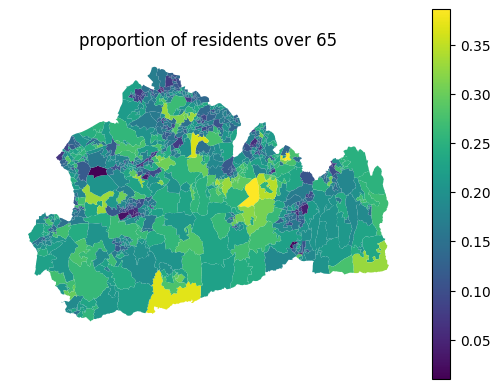

In [72]:
ax = read_gdb("lsoa").merge(
    gdf_joiner, on="lsoa21_code"
).plot(column="proportion_over_65", legend=True)
ax.set_title("proportion of residents over 65")
ax.set_axis_off()